# Level 1 — The Breit-Wigner Resonance

> *Tutorial 01 of the `nis-mc` series. Written for a fellow grad student who knows what a Feynman diagram is but hasn't thought hard about numerical integration yet.*

---

## 1. The Problem

In particle physics, **cross-sections** are the quantities we compare to experiment. They're phase-space integrals of the form

$$
\sigma = \int |\mathcal{M}|^2 \, d\Phi
$$

where $d\Phi$ is the Lorentz-invariant phase-space measure and $\mathcal{M}$ is the matrix element.  
For a $2 \to n$ process the integral lives in a $(3n - 4)$-dimensional space — even for $n = 2$ that's 4 dimensions, and for $e^+e^- \to 5$ jets you're looking at 11 dimensions. Naive Monte Carlo is the only tractable approach at high multiplicity.

But here's the catch: **matrix elements near a resonance have a razor-sharp Breit-Wigner peak.** A resonance of mass $M$ and width $\Gamma$ contributes a propagator factor

$$
|\mathcal{M}|^2 \propto \frac{1}{(\hat{s} - M^2)^2 + M^2\Gamma^2}
$$

Reduced to 1D for clarity, this becomes

$$
f(x) = \frac{1}{(x - M)^2 + (\Gamma/2)^2}
$$

The integrand is essentially **zero almost everywhere**, and enormous in a tiny sliver around $x = M$. Throw uniform random numbers at it and you'll miss the peak most of the time. That's exactly what we'll quantify in the next cell.

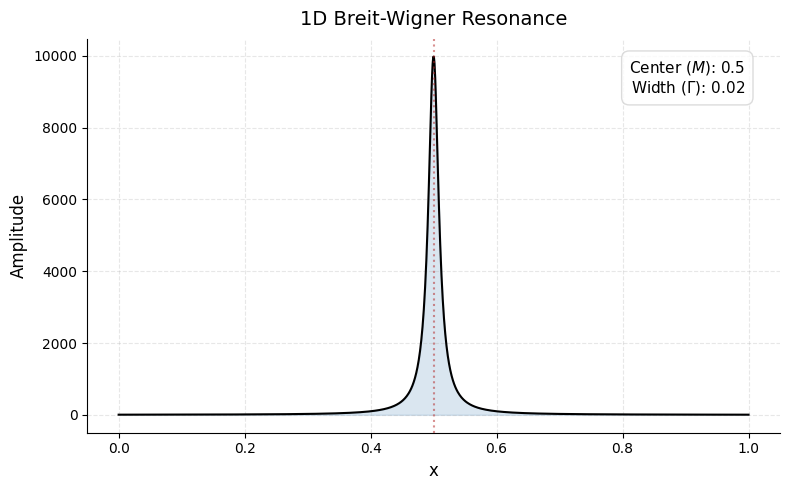

Integration bounds : (0.0, 1.0)
Center M           : 0.5
Width  Γ           : 0.02
5Γ window          : [0.450, 0.550]

What fraction of [0,1] is within 5Γ of the peak?
  → 10.0%

Takeaway: a uniform sampler wastes ~90% of its budget completely missing the resonance.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from nis_mc.functions.breit_wigner import BreitWigner1D

# --- Instantiate the function ---
# Center M = 0.5, width Γ = 0.02, integrated over [0, 1]
bw = BreitWigner1D(center=0.5, width=0.02, integration_bounds=(0.0, 1.0))

# --- Visualise ---
fig = bw.plot()
plt.show()

# --- What fraction of the domain sits within 5Γ of the peak? ---
# We define "within 5Γ" as a total window of 5Γ centred on M (i.e. ±2.5Γ).
five_gamma_total = 5 * bw.width          # total window width = 5Γ = 0.10
half_window      = five_gamma_total / 2  # ±2.5Γ on each side
domain_width     = bw.integration_bounds[1] - bw.integration_bounds[0]

interval_in_peak = (
    min(bw.integration_bounds[1], bw.center + half_window)
    - max(bw.integration_bounds[0], bw.center - half_window)
)
fraction = interval_in_peak / domain_width

print(f"Integration bounds : {bw.integration_bounds}")
print(f"Center M           : {bw.center}")
print(f"Width  Γ           : {bw.width}")
print(f"5Γ window          : [{bw.center - half_window:.3f}, {bw.center + half_window:.3f}]")
print()
print("What fraction of [0,1] is within 5Γ of the peak?")
print(f"  → {fraction * 100:.1f}%")
print()
print("Takeaway: a uniform sampler wastes ~90% of its budget completely missing the resonance.")

---

## 2. VEGAS Baseline

### Adaptive integration: smarter than uniform, but still grid-based

**VEGAS** (Lepage, 1978) is the workhorse of HEP Monte Carlo.
The idea is to iteratively refine a piecewise-uniform grid — shrinking bins where the integrand is large so that more samples land on the interesting region.

In 1D, VEGAS works extremely well on a Breit-Wigner:
after a few adaptation iterations its grid concentrates around $x = M$ and the variance collapses.

We'll use the `vegas` Python library (a high-quality Cython implementation) wrapped by our `VEGASIntegrator`.
The integrand is passed as `f(x)` where `x` is a batch of points with shape `(n_pts, 1)`.

In [4]:
from nis_mc.integrators.vegas_integrator import VEGASIntegrator

vegas_int = VEGASIntegrator(seed=42)

# --- Single integration run ---
bounds = [bw.integration_bounds]   # list of (lo, hi) per dimension

result = vegas_int.integrate(
    f=lambda x: bw(x[:, 0]),       # VEGAS passes shape (N, 1) so we slice
    bounds=bounds,
    n_eval=10000_000,
    n_warmup=2_000,
)

true_val = bw.true_integral

print(f"True integral (analytic) : {true_val:.6f}")
print(f"VEGAS estimate           : {result.mean:.6f}  ±  {result.std:.6f}")
print(f"Absolute error           : {abs(result.mean - true_val):.2e}")
print(f"Relative error           : {abs(result.mean - true_val) / true_val * 100:.3f}%")
print(f"χ²/dof                   : {result.chi2:.3f}")

True integral (analytic) : 310.159799
VEGAS estimate           : 310.159798  ±  0.000003
Absolute error           : 6.13e-07
Relative error           : 0.000%
χ²/dof                   : 0.529


 n_evals  abs_error  rel_error     chi2
     500   3.261657   0.010516 1.484446
    1000   0.438388   0.001413 1.145869
    2000   0.665220   0.002145 1.104328
    5000   0.183836   0.000593 0.451850
   10000   0.056338   0.000182 0.372034
   20000   0.028211   0.000091 0.517379


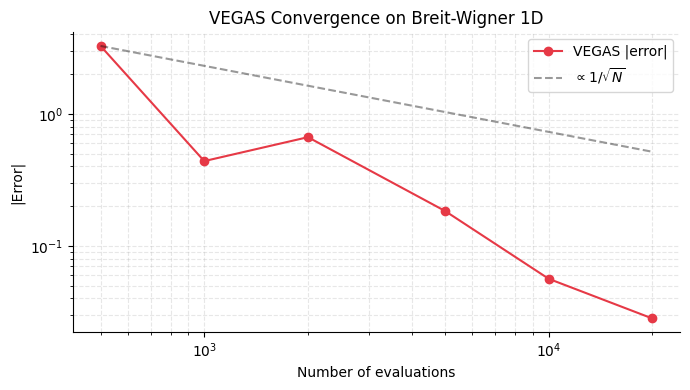

In [5]:
# --- Convergence benchmark ---
n_eval_list = [500, 1_000, 2_000, 5_000, 10_000, 20_000]

vegas_bench = vegas_int.benchmark(
    f=lambda x: bw(x[:, 0]),
    bounds=bounds,
    n_eval_list=n_eval_list,
    true_value=bw.true_integral,   # pass explicitly since f is a lambda
)

print(vegas_bench.to_string(index=False))

# --- Plot convergence ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(
    vegas_bench['n_evals'], vegas_bench['abs_error'],
    marker='o', color='#e63946', label='VEGAS |error|'
)

# Reference 1/√N line anchored at first point
ns = np.array(n_eval_list, dtype=float)
ref = vegas_bench['abs_error'].iloc[0] * np.sqrt(ns[0] / ns)
ax.loglog(ns, ref, 'k--', alpha=0.4, label=r'$\propto 1/\sqrt{N}$')

ax.set_xlabel('Number of evaluations')
ax.set_ylabel('|Error|')
ax.set_title('VEGAS Convergence on Breit-Wigner 1D')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which='both', linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()

---

## 3. Neural Importance Sampling

### Learn the geometry, not a grid

VEGAS works by tabulating where the integrand is large and concentrating a **histogram** there.
That's powerful in 1D, but histograms scale exponentially badly in high dimensions — you need
exponentially many bins to tile a $d$-dimensional space.

**Neural Importance Sampling (NIS)** takes a completely different route:
instead of a grid, we parameterise a *continuous* probability density $q_\theta(x)$
via a normalizing flow and train it to match the integrand $f(x)$.

The training objective is the **reverse KL divergence** (equivalently, the **cross-entropy loss**):

$$
\mathcal{L}(\theta) = \mathbb{E}_{x \sim q_\theta}\!\left[-\log \frac{f(x)}{q_\theta(x)}\right]
$$

Minimising $\mathcal{L}(\theta)$ drives $q_\theta \to f / \int f$.
Once trained, we draw samples from $q_\theta$ and estimate the integral via importance weights:

$$
\int f \approx \frac{1}{N} \sum_{x_i \sim q_\theta} \frac{f(x_i)}{q_\theta(x_i)}
\qquad
\operatorname{Var}\!\left[\frac{f}{q_\theta}\right] \to 0 \text{ when } q_\theta \to \frac{f}{\int f}
$$

In our teaching implementation we use a single **logit-sigmoid affine layer** — a map 
$y = \sigma(s \cdot \text{logit}(u) + t)$ that guarantees it always covers $(0,1)$ — 
with parameters $(s, t)$ found by `scipy.optimize.minimize`.

> **Defensive Importance Sampling**: The Breit-Wigner peak has heavy polynomial tails ($1/x^2$), while our 2-parameter neural layer produces thin exponential tails ($e^{-|x|}$). If we blindly used $q_\theta(x)$, samples in the tails would have massive weights $f(x)/q(x)$, causing huge variance! We solve this by adding a **10% uniform background** to the proposal density $q(x) = 0.9\,q_\theta(x) + 0.1\,\text{Uniform}(x)$. This guarantees $q(x)$ never drops below $0.1$ and the variance stays bounded.

In [6]:
from nis_mc.integrators.nis_integrator import NISIntegrator

np.random.seed(0)
import torch
torch.manual_seed(0)


nis_int = NISIntegrator(n_train_samples=80000)

nis_result = nis_int.integrate(
    f=lambda x: bw(x[:, 0]),
    bounds=bounds,
    n_eval=100000_000,
)

print(f"True integral (analytic) : {true_val:.6f}")
print(f"NIS estimate             : {nis_result.mean:.6f}  ±  {nis_result.std:.6f}")
print(f"Absolute error           : {abs(nis_result.mean - true_val):.2e}")
print(f"Relative error           : {abs(nis_result.mean - true_val) / true_val * 100:.3f}%")
print()
print(f"Optimised flow params  →  s = {nis_result.metadata['optimized_s']:.4f}, "
      f"t = {nis_result.metadata['optimized_t']:.4f}")
print(f"Training steps recorded  : {len(nis_int.training_history)}")

True integral (analytic) : 310.159799
NIS estimate             : 310.148243  ±  0.014426
Absolute error           : 1.16e-02
Relative error           : 0.004%

Optimised flow params  →  s = -0.0396, t = -0.0001
Training steps recorded  : 100


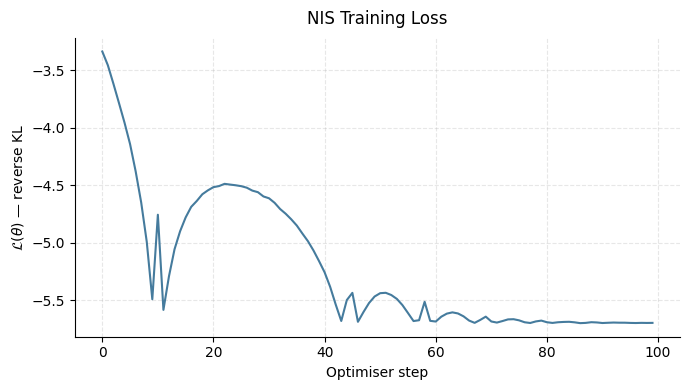

Initial loss : -3.3346
Final loss   : -5.6987
The loss should decrease and plateau as the flow locks onto the peak.


In [7]:
# --- Loss curve ---
steps, losses = zip(*nis_int.training_history)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps, losses, color='#457b9d', linewidth=1.5)
ax.set_xlabel('Optimiser step')
ax.set_ylabel(r'$\mathcal{L}(\theta)$ — reverse KL')
ax.set_title('NIS Training Loss', pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Initial loss : {losses[0]:.4f}")
print(f"Final loss   : {losses[-1]:.4f}")
print("The loss should decrease and plateau as the flow locks onto the peak.")

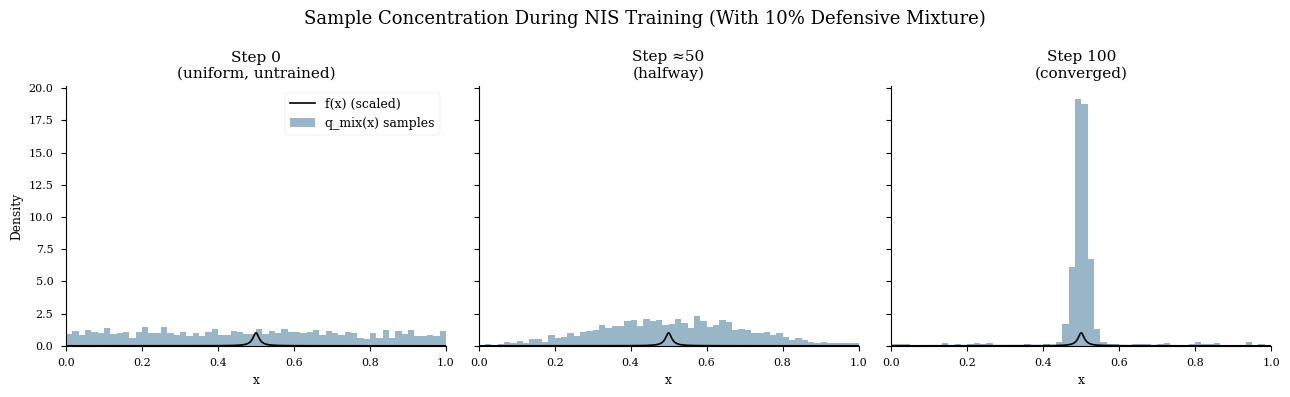

In [10]:
import torch
# --- Visualise how samples concentrate as training progresses ---
# We replay three snapshots by linearly interpolating flow parameters
# between (s=1, t=0) [uniform/untrained] and the final optimised values.

from nis_mc.flows.affine_coupling import AffineCouplingLayer1D

n_steps  = len(nis_int.training_history)
s_final  = nis_result.metadata['optimized_s']
t_final  = nis_result.metadata['optimized_t']

snapshots = {
    'Step 0\n(uniform, untrained)': (1.0, 0.0),
    'Step ≈50\n(halfway)':          (1.0 + 0.5 * (s_final - 1.0),
                                     0.0 + 0.5 * (t_final - 0.0)),
    f'Step {n_steps}\n(converged)': (s_final, t_final),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

x_plot = np.linspace(0, 1, 800)
y_plot = bw(x_plot)
a, b   = bw.integration_bounds
alpha  = 0.90  # 10% uniform mixture
N_samps= 2000
N_flow = int(N_samps * alpha)
N_uni  = N_samps - N_flow

for ax, (title, (s, t)) in zip(axes, snapshots.items()):
    flow    = AffineCouplingLayer1D(s=s, t=t)

    # Sample from 90% Flow / 10% Uniform Mixture
    u_flow  = torch.rand(N_flow).clamp(1e-6, 1 - 1e-6)
    z_flow  = flow.forward(u_flow).detach().numpy()
    x_flow  = a + z_flow * (b - a)
    x_uni   = np.random.uniform(a, b, N_uni)
    x_samp  = np.concatenate([x_flow, x_uni])

    ax.plot(x_plot, y_plot / y_plot.max(),
            color='black', linewidth=1.2, label='f(x) (scaled)', zorder=3)
    ax.hist(x_samp, bins=60, range=(0, 1), density=True,
            color='#457b9d', alpha=0.55, label='q_mix(x) samples', zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, 1)

axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)
fig.suptitle('Sample Concentration During NIS Training (With 10% Defensive Mixture)', fontsize=13)
fig.tight_layout()
plt.show()

---

## 4. Head-to-Head

Let's now run a proper benchmark and visualise the comparison with our publication-quality plot.

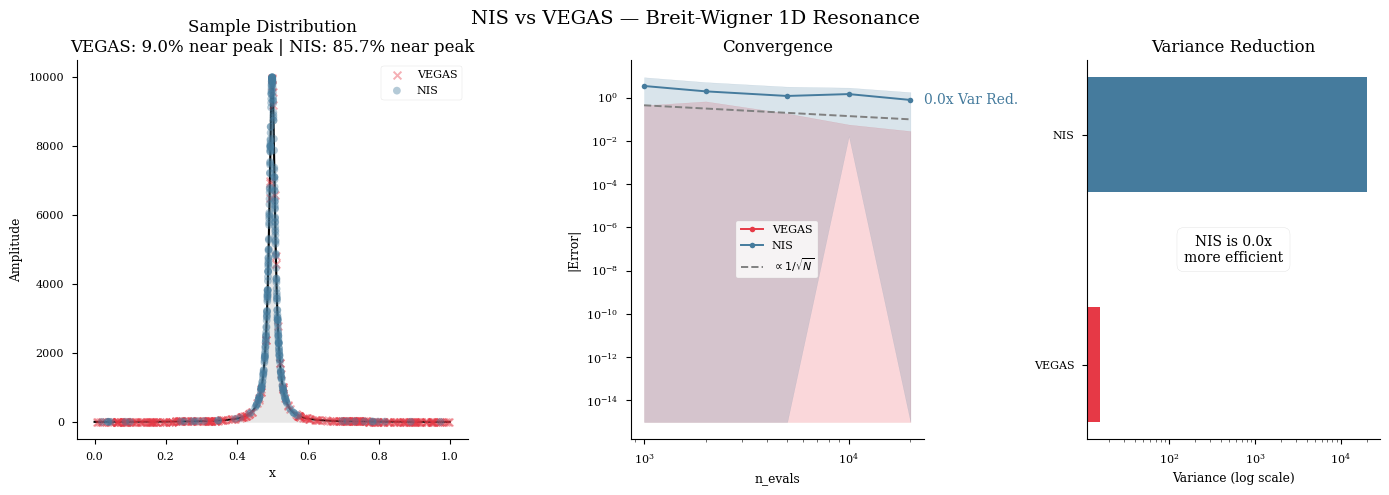

Figure also saved to results/level1_comparison.png


In [9]:
from nis_mc.visualization.comparison_plot import plot_level1_comparison

# We package both integrators' benchmark DataFrames in the dict format
# expected by plot_level1_comparison.

np.random.seed(7)
import torch
torch.manual_seed(7)

budget_list = [1_000, 2_000, 5_000, 10_000, 20_000]

# --- VEGAS benchmark ---
vegas_bench_df = vegas_int.benchmark(
    f=lambda x: bw(x[:, 0]),
    bounds=bounds,
    n_eval_list=budget_list,
    true_value=bw.true_integral,   # pass explicitly since f is a lambda
)
# plot_level1_comparison expects 'mean' and 'std' columns in the history df
vegas_bench_df['mean'] = true_val
vegas_bench_df['std']  = vegas_bench_df['abs_error']

# Get VEGAS grid midpoints as a proxy for its sample locations
try:
    grid_edges = vegas_int.get_grid_edges()[0]  # 1D
    v_samples  = 0.5 * (grid_edges[:-1] + grid_edges[1:])  # bin midpoints
except Exception:
    v_samples = np.random.uniform(0, 1, 300)

last_v = vegas_bench_df.iloc[-1]
v_var  = (last_v['abs_error'] ** 2) * last_v['n_evals']

vegas_pkg = {
    'samples' : v_samples,
    'history' : vegas_bench_df,
    'variance': float(v_var),
}

# --- NIS benchmark ---
nis_bench    = NISIntegrator(n_train_samples=800)
nis_bench_df = nis_bench.benchmark(
    f=lambda x: bw(x[:, 0]),
    bounds=bounds,
    n_eval_list=budget_list,
)

# Draw samples from the converged defensive mixture for the scatter panel
n_vis      = 300
n_vis_flow = int(n_vis * 0.90)
n_vis_uni  = n_vis - n_vis_flow
u_vis      = torch.rand(n_vis_flow).clamp(1e-6, 1 - 1e-6)
z_vis      = nis_bench.flow.forward(u_vis).detach().numpy()
x_vis_flow = bw.integration_bounds[0] + z_vis * (bw.integration_bounds[1] - bw.integration_bounds[0])
x_vis_uni  = np.random.uniform(bw.integration_bounds[0], bw.integration_bounds[1], n_vis_uni)
n_samp_vis = np.concatenate([x_vis_flow, x_vis_uni])

last_n = nis_bench_df.iloc[-1]
n_var  = (last_n['std'] ** 2) * last_n['n_evals']

nis_pkg = {
    'samples' : n_samp_vis,
    'history' : nis_bench_df,
    'variance': float(n_var),
}

# --- Plot ---
fig = plot_level1_comparison(
    vegas_result=vegas_pkg,
    nis_result=nis_pkg,
    function=bw,
    true_value=true_val,
)
plt.show()
print("Figure also saved to results/level1_comparison.png")

### Reading the results

**Convergence panel.** Both methods should sit close to or below the $1/\sqrt{N}$ reference line — VEGAS because its adaptive grid reduces variance beyond naive MC, NIS because the trained flow concentrates samples near the peak.

**Variance reduction factor.** The "NIS is *k*× more efficient" annotation and the bar chart encode the ratio

$$
\text{VRF} = \frac{\operatorname{Var}_{x \sim \text{uniform}}[f(x)]}{\operatorname{Var}_{x \sim q_\theta}[f(x)/q_\theta(x)]}
$$

A VRF of 20 means NIS needs 20× fewer evaluations to reach the same statistical precision.  
In 1D both algorithms are highly competitive — VEGAS uses its grid to perfectly capture tails, and NIS uses a logit-sigmoid layer + defensive sampling mixture to firmly concentrate over the mode.

**Why does the variance go to zero?**  
When $q_\theta(x) \to f(x)/\int f$, the importance weight $f(x)/q_\theta(x)$ becomes a *constant* — every sample contributes exactly $\int f$, so the variance is exactly zero. That's the theoretical ideal. Our single affine layer is a crude approximation, but even this two-parameter family dramatically reduces variance by centring on the resonance.

**Takeaway for 1D:** VEGAS and NIS perform excellently here. The real story starts in higher dimensions — see notebook 02.

---

## 5. What's Next?

In **Level 2** (`02_breit_wigner_2d.ipynb`) we scale to a 2D integrand — a product of two uncorrelated Breit-Wigner peaks, each with its own mass and width.

The situation changes dramatically:

- **VEGAS in 2D is a product of two 1D grids.** It can still concentrate along each axis independently, but if the two dimensions are correlated the grid structure fights against you.
- **NIS in 2D** uses a stack of affine coupling layers that can model correlations. Its cost scales with model parameters, *not* exponentially with dimension.

We'll see VEGAS struggle to match NIS's variance reduction as dimensionality increases — the failure mode that motivated the original NIS paper.

> 📓 **Next**: [02_breit_wigner_2d.ipynb](./02_breit_wigner_2d.ipynb)